# 3.1. Сбор, подготовка и предварительный анализ данных

Блокнот для первого параграфа третьей главы. В нем выполняются базовые расчеты по файлу `data/processed/vacancies_for_model_final.csv`: структура данных, пропуски, дубли, описательная статистика, проверка выбросов, проверка нормальности и графики для вставки в Word.

## 1. Подключение библиотек и загрузка данных

Используются базовые библиотеки: `pandas`, `numpy`, `matplotlib`, `scipy`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

DATA_PATH = Path('../data/processed/vacancies_for_model_final.csv')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

column_names_ru = {
    'vacancy_id': 'ID вакансии',
    'name': 'Название вакансии',
    'alternate_url': 'Ссылка',
    'employer_name': 'Работодатель',
    'area_name': 'Город / регион',
    'city_group': 'Городская группа',
    'experience_name': 'Опыт работы',
    'schedule_name': 'Формат работы',
    'employment_name': 'Тип занятости',
    'salary_from': 'Зарплата от',
    'salary_to': 'Зарплата до',
    'salary_currency': 'Валюта',
    'salary_gross': 'Gross',
    'has_salary': 'Есть зарплата',
    'salary_mid': 'Средняя зарплата',
    'key_skills': 'Ключевые навыки',
    'description_text': 'Описание вакансии',
    'primary_role': 'Направление аналитики',
    'is_business_analyst': 'Бизнес-аналитика',
    'is_system_analyst': 'Системная аналитика',
    'is_bi_analyst': 'BI/DWH-аналитика',
    'is_data_analyst': 'Аналитика данных',
    'is_product_analyst': 'Продуктовая аналитика',
    'is_ds_ml': 'DS/ML',
    'has_sql': 'SQL',
    'has_python': 'Python',
    'has_excel': 'Excel',
    'has_power_bi': 'Power BI',
    'has_tableau': 'Tableau',
    'has_bi_tools': 'BI-инструменты',
    'has_dwh': 'DWH',
    'has_etl': 'ETL',
    'has_ml': 'ML',
    'has_statistics': 'Статистика',
    'has_ab_testing': 'A/B-тестирование',
    'has_bpmn': 'BPMN',
    'has_uml': 'UML',
    'has_api': 'API',
    'has_requirements': 'Требования / ТЗ',
    'has_1c': '1C',
    'has_jira': 'Jira / Confluence',
}

group_names_ru = {
    'primary_role': 'Направление аналитики',
    'city_group': 'Городская группа',
    'experience_name': 'Опыт работы',
    'schedule_name': 'Формат работы',
}

salary_stat_names_ru = {
    'count': 'Количество',
    'mean': 'Среднее',
    'median': 'Медиана',
    'min': 'Минимум',
    'max': 'Максимум',
    'std': 'Стандартное отклонение',
}

print('Размер исходной выборки:', df.shape)
df.head().rename(columns=column_names_ru)

Размер исходной выборки: (693, 41)


,ID вакансии,Название вакансии,Ссылка,Работодатель,Город / регион,Городская группа,Опыт работы,Формат работы,Тип занятости,Зарплата от,Зарплата до,Валюта,Gross,Есть зарплата,Средняя зарплата,Ключевые навыки,Описание вакансии,Направление аналитики,Бизнес-аналитика,Системная аналитика,BI/DWH-аналитика,Аналитика данных,Продуктовая аналитика,DS/ML,SQL,Python,Excel,Power BI,Tableau,BI-инструменты,DWH,ETL,ML,Статистика,A/B-тестирование,BPMN,UML,API,Требования / ТЗ,1C,Jira / Confluence
0,133289938,Junior Бизнес-аналитик,https://hh.ru/vacancy/133289938,Metacommerce,Казань,Регионы,От 1 года до 3 лет,Удалённо,Полная,80000.0,120000.0,RUR,False,1,100000.0,"Бизнес-анализ, Power BI, SQL, Управление ожида...",Развиваем собственный IT-продукт для работы с ...,Business Analytics,1,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,0
1,133169592,Бизнес-аналитик,https://hh.ru/vacancy/133169592,РамСар,Казань,Регионы,От 1 года до 3 лет,На месте работодателя,Полная,150000.0,NaN,RUR,True,1,150000.0,NaN,Чем предстоит заниматься: Проведение комплексн...,Business Analytics,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,133069549,Бизнес-аналитик,https://hh.ru/vacancy/133069549,Нэфис Косметикс,Казань,Регионы,От 1 года до 3 лет,На месте работодателя,Полная,100000.0,NaN,RUR,True,1,100000.0,"Альт-Инвест, Планирование, Аналитическое мышле...","АО ""Нэфис Косметикс"" - динамично развивающаяся...",Business Analytics,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,133085193,Бизнес-аналитик 1С:ERP по РСБУ,https://hh.ru/vacancy/133085193,Агросила,Казань,Регионы,От 1 года до 3 лет,"На месте работодателя, Удалённо, Гибрид",Полная,140000.0,150000.0,RUR,True,1,145000.0,NaN,В связи с созданием проекта по внедрению 1С:ER...,Business Analytics,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0
4,133054530,Бизнес/Системный аналитик (1С-Битрикс),https://hh.ru/vacancy/133054530,Ай-Пласт,Казань,Регионы,От 3 до 6 лет,Удалённо,Полная,190000.0,NaN,RUR,False,1,190000.0,"Бизнес-анализ, Системный анализ, BPMN, BABOK, ...",Plast— лидер рынка переработки полимеров и про...,System Analytics,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,1,1,1,1,1


## 2. Структура датасета

Проверяем количество строк, столбцов и типы данных.

In [2]:
print('Количество вакансий:', len(df))
print('Количество переменных:', df.shape[1])

structure = pd.DataFrame({
    'Переменная': df.columns,
    'Тип данных': [str(df[col].dtype) for col in df.columns],
    'Количество пропусков': [df[col].isna().sum() for col in df.columns],
    'Доля пропусков, %': [round(df[col].isna().mean() * 100, 2) for col in df.columns],
})
structure

Количество вакансий: 693
Количество переменных: 41


,Переменная,Тип данных,Количество пропусков,"Доля пропусков, %"
0,vacancy_id,int64,0,0.00
1,name,str,0,0.00
2,alternate_url,str,0,0.00
3,employer_name,str,0,0.00
4,area_name,str,0,0.00
5,city_group,str,0,0.00
6,experience_name,str,0,0.00
7,schedule_name,str,15,2.16
8,employment_name,str,0,0.00
9,salary_from,float64,126,18.18


## 3. Проверка дублей и пропусков

По требованиям нужно проверить дубли и пропуски. Для зарплатного анализа главная переменная - `salary_mid`.

In [3]:
duplicate_vacancies = df['vacancy_id'].duplicated().sum()
print('Дубли по vacancy_id:', duplicate_vacancies)

important_columns = [
    'vacancy_id', 'name', 'primary_role', 'city_group',
    'experience_name', 'schedule_name', 'salary_from', 'salary_to',
    'salary_currency', 'salary_mid'
]

missing_important = pd.DataFrame({
    'Переменная': [column_names_ru.get(col, col) for col in important_columns],
    'Количество пропусков': [df[col].isna().sum() for col in important_columns],
    'Доля пропусков, %': [round(df[col].isna().mean() * 100, 2) for col in important_columns],
})
missing_important

Дубли по vacancy_id: 0


,Переменная,Количество пропусков,"Доля пропусков, %"
0,ID вакансии,0,0.00
1,Название вакансии,0,0.00
2,Направление аналитики,0,0.00
3,Городская группа,0,0.00
4,Опыт работы,0,0.00
5,Формат работы,15,2.16
6,Зарплата от,126,18.18
7,Зарплата до,267,38.53
8,Валюта,0,0.00
9,Средняя зарплата,0,0.00


## 4. Проверка валюты и зарплатных полей

Для анализа используются вакансии с зарплатой в рублях. `salary_mid` рассчитывается как середина вилки, если указаны обе границы, или как единственная указанная граница, если работодатель указал только `salary_from` или только `salary_to`.

In [4]:
print('Распределение валют:')
print(df['salary_currency'].value_counts(dropna=False))

salary_fields = df[['salary_from', 'salary_to', 'salary_mid']].describe().T
salary_fields = salary_fields.rename(index=column_names_ru, columns=salary_stat_names_ru)
salary_fields

Распределение валют:
salary_currency
RUR    693
Name: count, dtype: int64


,Количество,Среднее,Стандартное отклонение,Минимум,25%,50%,75%,Максимум
Зарплата от,567.0,145532.756614,80212.642731,150.0,80000.0,131200.0,200000.0,512000.0
Зарплата до,426.0,205487.248826,100854.685369,1500.0,130000.0,200000.0,250000.0,768000.0
Средняя зарплата,693.0,169998.085137,92190.089857,1050.0,100000.0,150000.0,225000.0,700000.0


## 5. Предварительная проверка выбросов

Проверяем выбросы тремя способами: здравый смысл, правило 3 сигм и ящичковая диаграмма. Для зарплатного анализа используем месячную зарплату в рублях, поэтому слишком маленькие значения считаются некорректными для данной задачи.

In [5]:
# Проверка по здравому смыслу
MIN_REASONABLE_SALARY = 20_000
MAX_REASONABLE_SALARY = 800_000

logic_outliers = df[(df['salary_mid'] < MIN_REASONABLE_SALARY) | (df['salary_mid'] > MAX_REASONABLE_SALARY)].copy()
print('Наблюдений вне разумного диапазона:', len(logic_outliers))
logic_outliers[['vacancy_id', 'name', 'primary_role', 'salary_from', 'salary_to', 'salary_mid', 'alternate_url']].rename(columns=column_names_ru)

Наблюдений вне разумного диапазона: 7


,ID вакансии,Название вакансии,Направление аналитики,Зарплата от,Зарплата до,Средняя зарплата,Ссылка
117,132748849,Бизнес-системный аналитик / Product Delivery Lead,System Analytics,1500.0,3000.0,2250.0,https://hh.ru/vacancy/132748849
135,133099278,Бизнес-аналитик (веб-разработка),Business Analytics,600.0,1500.0,1050.0,https://hh.ru/vacancy/133099278
358,132400183,Аналитик данных,Data Analytics,7000.0,NaN,7000.0,https://hh.ru/vacancy/132400183
589,132369270,Специалист по разметке данных для машинного об...,DS/ML Analytics,15000.0,NaN,15000.0,https://hh.ru/vacancy/132369270
672,132296468,Аналитик данных,Data Analytics,7000.0,NaN,7000.0,https://hh.ru/vacancy/132296468
673,132292624,Аналитик данных,Data Analytics,7000.0,NaN,7000.0,https://hh.ru/vacancy/132292624
674,132292162,Аналитик данных,Data Analytics,6300.0,NaN,6300.0,https://hh.ru/vacancy/132292162


In [6]:
# Рабочая выборка после удаления некорректных зарплатных значений
df_clean = df[(df['salary_mid'] >= MIN_REASONABLE_SALARY) & (df['salary_mid'] <= MAX_REASONABLE_SALARY)].copy()
print('Исходная выборка:', len(df))
print('Рабочая выборка для анализа зарплат:', len(df_clean))
print('Удалено наблюдений:', len(df) - len(df_clean))

Исходная выборка: 693
Рабочая выборка для анализа зарплат: 686
Удалено наблюдений: 7


In [7]:
# Правила 3 сигм и 5 сигм для salary_mid в рабочей выборке
mean_salary = df_clean['salary_mid'].mean()
std_salary = df_clean['salary_mid'].std()

sigma_results = []
for k in [3, 5]:
    lower = mean_salary - k * std_salary
    upper = mean_salary + k * std_salary
    outliers = df_clean[(df_clean['salary_mid'] < lower) | (df_clean['salary_mid'] > upper)]
    sigma_results.append([k, round(lower, 2), round(upper, 2), len(outliers)])

sigma_table = pd.DataFrame(
    sigma_results,
    columns=['Правило', 'Нижняя граница', 'Верхняя граница', 'Количество потенциальных выбросов']
)
sigma_table['Правило'] = sigma_table['Правило'].map(lambda x: f'{x} сигм')
sigma_table

,Правило,Нижняя граница,Верхняя граница,Количество потенциальных выбросов
0,3 сигм,-101807.67,445140.25,4
1,5 сигм,-284123.64,627456.22,2


In [8]:
# Межквартильный размах для salary_mid
q1 = df_clean['salary_mid'].quantile(0.25)
q3 = df_clean['salary_mid'].quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr

outliers_iqr = df_clean[(df_clean['salary_mid'] < lower_iqr) | (df_clean['salary_mid'] > upper_iqr)]

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)
print('Нижняя граница ящичковой диаграммы:', lower_iqr)
print('Верхняя граница ящичковой диаграммы:', upper_iqr)
print('Выбросов по ящичковой диаграмме:', len(outliers_iqr))
outliers_iqr[['vacancy_id', 'name', 'primary_role', 'salary_mid']].sort_values('salary_mid', ascending=False).head(20).rename(columns=column_names_ru).reset_index(drop=True)

Q1: 100000.0
Q3: 225000.0
IQR: 125000.0
Нижняя граница ящичковой диаграммы: -87500.0
Верхняя граница ящичковой диаграммы: 412500.0
Выбросов по ящичковой диаграмме: 8


,ID вакансии,Название вакансии,Направление аналитики,Средняя зарплата
0,133108790,Senior Data Scientist (Recommender Systems / M...,DS/ML Analytics,700000.0
1,131040143,ML Engineer (Medical Imaging),DS/ML Analytics,640000.0
2,133208893,"Системный аналитик (Senior), мобильное приложе...",System Analytics,500000.0
3,132334576,Продуктовый аналитик,Product Analytics,500000.0
4,132992073,Продуктовый аналитик (Потребительское кредитов...,Product Analytics,425000.0
5,133220194,Tech Lead ML Engineer (Python),DS/ML Analytics,425000.0
6,133132082,Системный аналитик Финтех (Middle/Senior),System Analytics,420000.0
7,133245894,Системный аналитик Forex/Banking (РФ),System Analytics,414450.0


## 6. Описательная статистика зарплаты

Рассчитываем среднее, медиану, квартильные значения, стандартное отклонение, коэффициент вариации, асимметрию и эксцесс.

In [9]:
salary = df_clean['salary_mid']

salary_stats = pd.DataFrame({
    'Показатель': [
        'Количество наблюдений', 'Среднее', 'Медиана', 'Минимум', 'Максимум',
        '1 квартиль', '3 квартиль', 'Дисперсия', 'Стандартное отклонение',
        'Коэффициент вариации, %', 'Асимметрия', 'Эксцесс'
    ],
    'Значение': [
        salary.count(),
        salary.mean(),
        salary.median(),
        salary.min(),
        salary.max(),
        salary.quantile(0.25),
        salary.quantile(0.75),
        salary.var(),
        salary.std(),
        salary.std() / salary.mean() * 100,
        salary.skew(),
        salary.kurtosis(),
    ]
})

salary_stats['Значение'] = salary_stats['Значение'].map(lambda x: f'{x:,.2f}'.replace(',', ' '))
salary_stats

,Показатель,Значение
0,Количество наблюдений,686.00
1,Среднее,171 666.29
2,Медиана,150 000.00
3,Минимум,25 000.00
4,Максимум,700 000.00
5,1 квартиль,100 000.00
6,3 квартиль,225 000.00
7,Дисперсия,8 309 778 431.79
8,Стандартное отклонение,91 157.99
9,"Коэффициент вариации, %",53.10


## 7. Проверка нормальности распределения зарплаты

Проверяем нормальность по гистограмме, QQ-графику, асимметрии, эксцессу и критериям Шапиро-Уилка и Жарка-Бера.

In [10]:
def format_p_value(value):
    if value < 0.01:
        return '< 0.01'
    return f'{value:.2f}'

def lilliefors_monte_carlo(values, simulations=5000, seed=42):
    values = np.asarray(values)
    n = len(values)
    z = np.sort((values - values.mean()) / values.std(ddof=1))
    ecdf = np.arange(1, n + 1) / n
    cdf = stats.norm.cdf(z)
    d_plus = np.max(ecdf - cdf)
    d_minus = np.max(cdf - (np.arange(0, n) / n))
    d_observed = max(d_plus, d_minus)

    rng = np.random.default_rng(seed)
    simulated = np.empty(simulations)
    for i in range(simulations):
        sample = rng.normal(size=n)
        z_sample = np.sort((sample - sample.mean()) / sample.std(ddof=1))
        cdf_sample = stats.norm.cdf(z_sample)
        ecdf_sample = np.arange(1, n + 1) / n
        simulated[i] = max(
            np.max(ecdf_sample - cdf_sample),
            np.max(cdf_sample - (np.arange(0, n) / n))
        )

    p_value = (np.sum(simulated >= d_observed) + 1) / (simulations + 1)
    return d_observed, p_value

normality_results = []

# Shapiro-Wilk лучше применять на выборках до 5000 наблюдений, здесь размер подходит
shapiro_stat, shapiro_p = stats.shapiro(salary)
jb_stat, jb_p = stats.jarque_bera(salary)
lilliefors_stat, lilliefors_p = lilliefors_monte_carlo(salary)

normality_results.append([
    'Шапиро-Уилка',
    f'{shapiro_stat:.2f}',
    format_p_value(shapiro_p),
    'нормальное' if shapiro_p >= 0.05 else 'не нормальное'
])
normality_results.append([
    'Жарка-Бера',
    f'{jb_stat:.2f}',
    format_p_value(jb_p),
    'нормальное' if jb_p >= 0.05 else 'не нормальное'
])
normality_results.append([
    'Лиллифорса',
    f'{lilliefors_stat:.2f}',
    format_p_value(lilliefors_p),
    'нормальное' if lilliefors_p >= 0.05 else 'не нормальное'
])

normality_table = pd.DataFrame(
    normality_results,
    columns=['Критерий', 'Значение критерия', 'p-value', 'Вывод при уровне значимости 0,05']
)
normality_table

,Критерий,Значение критерия,p-value,"Вывод при уровне значимости 0,05"
0,Шапиро-Уилка,0.93,< 0.01,не нормальное
1,Жарка-Бера,297.39,< 0.01,не нормальное
2,Лиллифорса,0.10,< 0.01,не нормальное


In [ ]:
bins = np.arange(0, 750001, 25000)

plt.figure(figsize=(9, 5))
plt.hist(salary, bins=bins, edgecolor='black', alpha=0.75)
plt.axvline(salary.mean(), color='red', linestyle='--', label='Среднее')
plt.axvline(salary.median(), color='green', linestyle='--', label='Медиана')
plt.title('Распределение salary_mid')
plt.xlabel('Зарплата, руб.')
plt.ylabel('Количество вакансий')
plt.xlim(0, 750000)
plt.xticks(np.arange(0, 750001, 100000), ['0', '100 тыс.', '200 тыс.', '300 тыс.', '400 тыс.', '500 тыс.', '600 тыс.', '700 тыс.'])
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_1_salary_hist.png', dpi=200)
plt.show()


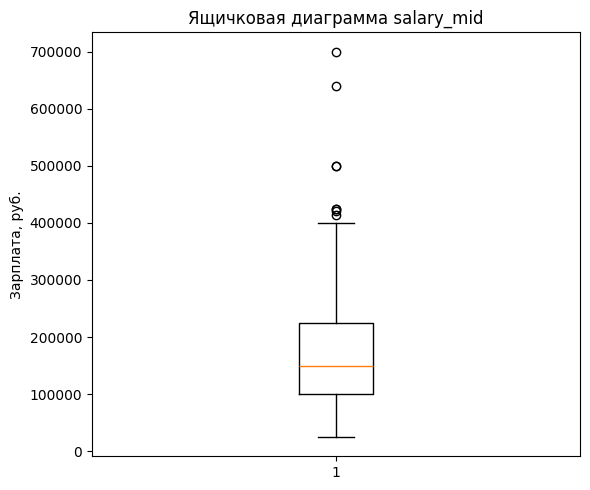

In [12]:
plt.figure(figsize=(6, 5))
plt.boxplot(salary, vert=True)
plt.title('Ящичковая диаграмма salary_mid')
plt.ylabel('Зарплата, руб.')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_2_salary_boxplot.png', dpi=200)
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
stats.probplot(salary, dist='norm', plot=plt)
plt.title('QQ-график salary_mid')
plt.xlabel('Теоретические квантили')
plt.ylabel('Выборочные квантили')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_3_salary_qqplot.png', dpi=200)
plt.show()


## 8. Распределение вакансий по основным признакам

Строим таблицы и графики по направлениям аналитики, городам, опыту и формату работы.

In [14]:
def frequency_table(data, column):
    counts = data[column].fillna('Не указано').value_counts()
    result = pd.DataFrame({
        'Категория': counts.index,
        'Количество': counts.values,
        'Доля, %': (counts.values / len(data) * 100).round(2),
    })
    return result.reset_index(drop=True)

role_table = frequency_table(df_clean, 'primary_role')
city_table = frequency_table(df_clean, 'city_group')
experience_table = frequency_table(df_clean, 'experience_name')
schedule_table = frequency_table(df_clean, 'schedule_name')

role_table

,Категория,Количество,"Доля, %"
0,System Analytics,248,36.15
1,Business Analytics,168,24.49
2,Data Analytics,106,15.45
3,DS/ML Analytics,70,10.20
4,BI/DWH Analytics,68,9.91
5,Product Analytics,26,3.79


In [15]:
city_table

,Категория,Количество,"Доля, %"
0,Москва,334,48.69
1,Регионы,279,40.67
2,Санкт-Петербург,73,10.64


In [16]:
experience_table

,Категория,Количество,"Доля, %"
0,От 1 года до 3 лет,290,42.27
1,От 3 до 6 лет,268,39.07
2,Нет опыта,70,10.20
3,Более 6 лет,58,8.45


In [17]:
schedule_table

,Категория,Количество,"Доля, %"
0,На месте работодателя,313,45.63
1,Удалённо,200,29.15
2,"На месте работодателя, Гибрид",64,9.33
3,Гибрид,47,6.85
4,"На месте работодателя, Удалённо, Гибрид",29,4.23
5,Не указано,15,2.19
6,"Удалённо, Гибрид",13,1.90
7,"На месте работодателя, Удалённо",5,0.73


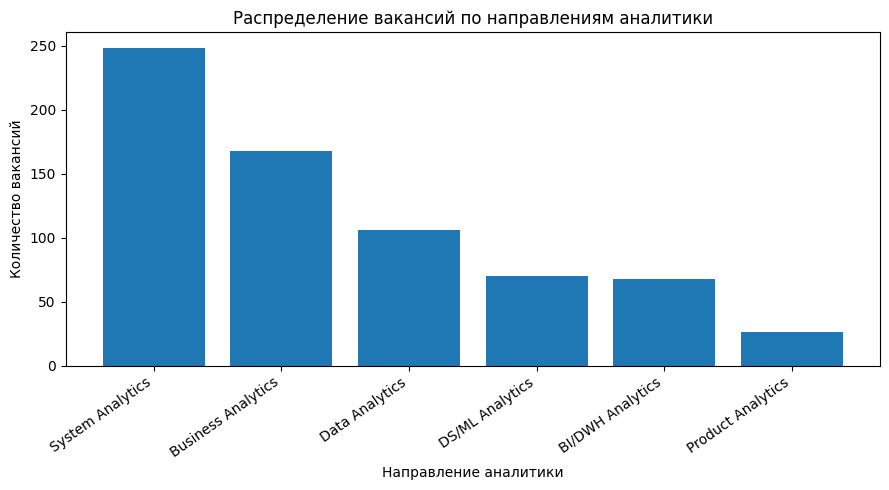

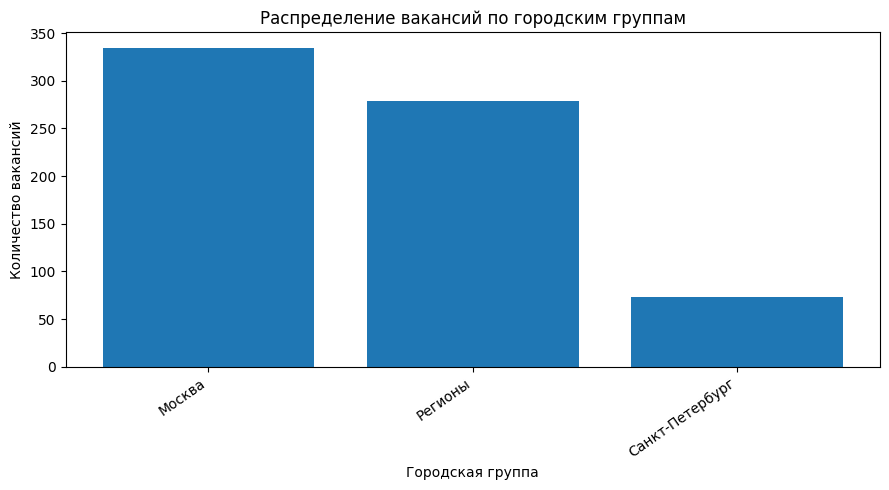

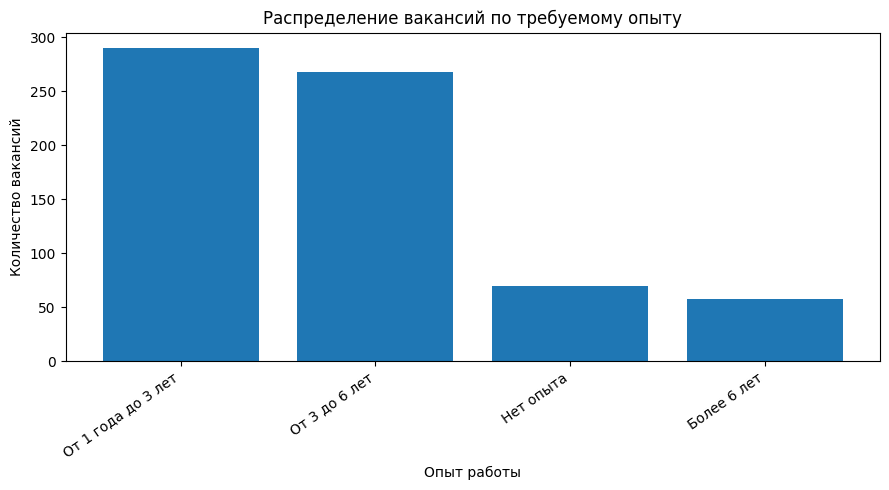

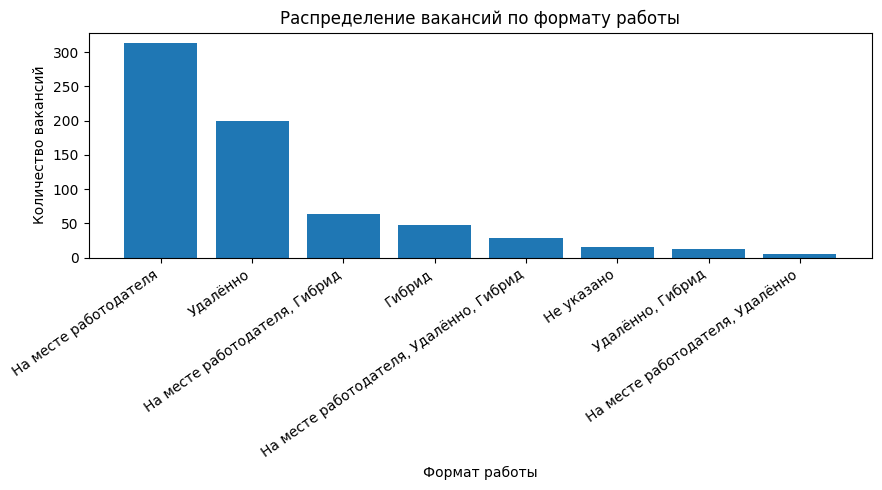

In [18]:
def bar_plot(table, title, xlabel, filename):
    plt.figure(figsize=(9, 5))
    plt.bar(table['Категория'], table['Количество'])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Количество вакансий')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200)
    plt.show()

bar_plot(role_table, 'Распределение вакансий по направлениям аналитики', 'Направление аналитики', 'fig_3_4_roles_count.png')
bar_plot(city_table, 'Распределение вакансий по городским группам', 'Городская группа', 'fig_3_5_city_count.png')
bar_plot(experience_table, 'Распределение вакансий по требуемому опыту', 'Опыт работы', 'fig_3_6_experience_count.png')
bar_plot(schedule_table, 'Распределение вакансий по формату работы', 'Формат работы', 'fig_3_7_schedule_count.png')

## 9. Зарплата по основным группам

Сравниваем среднюю и медианную зарплату по направлениям аналитики, городам, опыту и формату работы. Подробная проверка гипотез будет выполняться в параграфе 3.3.

In [19]:
def group_salary_table(data, group_col):
    result = (
        data
        .groupby(group_col, dropna=False)['salary_mid']
        .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
        .reset_index()
    )
    result[['mean', 'median', 'min', 'max', 'std']] = result[['mean', 'median', 'min', 'max', 'std']].round(2)
    result = result.sort_values('median', ascending=False).reset_index(drop=True)
    result = result.rename(columns={group_col: group_names_ru.get(group_col, group_col), **salary_stat_names_ru})
    return result

salary_by_role = group_salary_table(df_clean, 'primary_role')
salary_by_city = group_salary_table(df_clean, 'city_group')
salary_by_experience = group_salary_table(df_clean, 'experience_name')
salary_by_schedule = group_salary_table(df_clean, 'schedule_name')

salary_by_role

,Направление аналитики,Количество,Среднее,Медиана,Минимум,Максимум,Стандартное отклонение
0,DS/ML Analytics,70,241639.86,200000.0,80000.0,700000.0,116501.67
1,Product Analytics,26,204533.85,200000.0,60000.0,500000.0,108445.53
2,System Analytics,248,182024.61,182000.0,30000.0,500000.0,92372.89
3,BI/DWH Analytics,68,163778.66,149712.5,25000.0,400000.0,77708.17
4,Business Analytics,168,151471.73,140000.0,40000.0,350000.0,71627.92
5,Data Analytics,106,130227.36,125000.0,30000.0,375000.0,64770.34


In [20]:
salary_by_city

,Городская группа,Количество,Среднее,Медиана,Минимум,Максимум,Стандартное отклонение
0,Москва,334,206939.65,200000.0,40000.0,700000.0,92077.61
1,Санкт-Петербург,73,179068.49,189500.0,50000.0,640000.0,86932.14
2,Регионы,279,127502.62,103500.0,25000.0,400000.0,69971.09


In [21]:
salary_by_experience

,Опыт работы,Количество,Среднее,Медиана,Минимум,Максимум,Стандартное отклонение
0,Более 6 лет,58,270965.52,250000.0,92000.0,700000.0,97810.77
1,От 3 до 6 лет,268,218557.23,200000.0,50000.0,640000.0,82355.82
2,От 1 года до 3 лет,290,130794.60,125000.0,25000.0,350000.0,56532.39
3,Нет опыта,70,79190.03,60000.0,30000.0,400000.0,49358.28


In [22]:
salary_by_schedule

,Формат работы,Количество,Среднее,Медиана,Минимум,Максимум,Стандартное отклонение
0,"Удалённо, Гибрид",13,251730.77,250000.0,77500.0,350000.0,81594.68
1,Гибрид,47,180000.00,200000.0,40000.0,350000.0,75871.75
2,Удалённо,200,198207.62,200000.0,25000.0,700000.0,106550.46
3,NaN,15,185066.67,184000.0,62000.0,350000.0,84960.05
4,"На месте работодателя, Гибрид",64,178858.98,182500.0,40000.0,500000.0,88801.81
5,"На месте работодателя, Удалённо, Гибрид",29,182500.00,170000.0,72500.0,350000.0,74624.06
6,"На месте работодателя, Удалённо",5,135000.00,135000.0,80000.0,230000.0,59371.71
7,На месте работодателя,313,147599.27,130000.0,30000.0,400000.0,77943.57


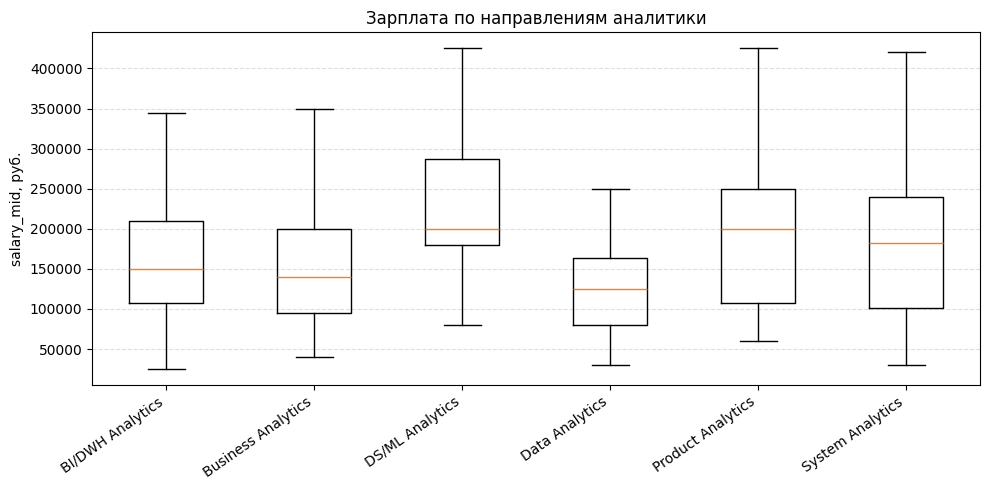

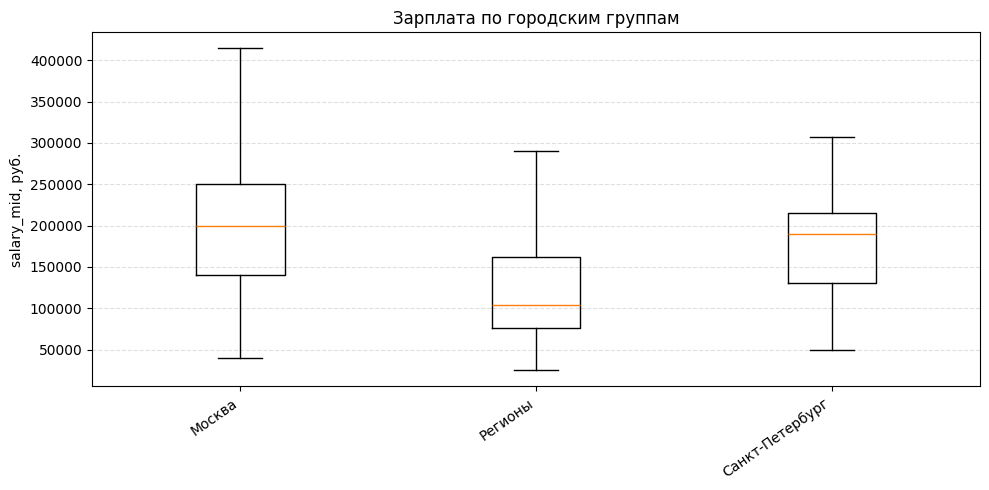

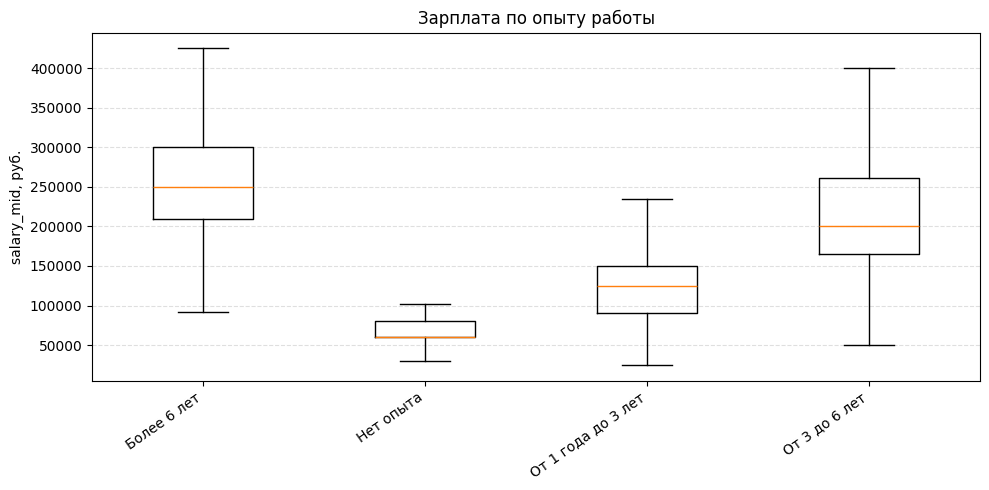

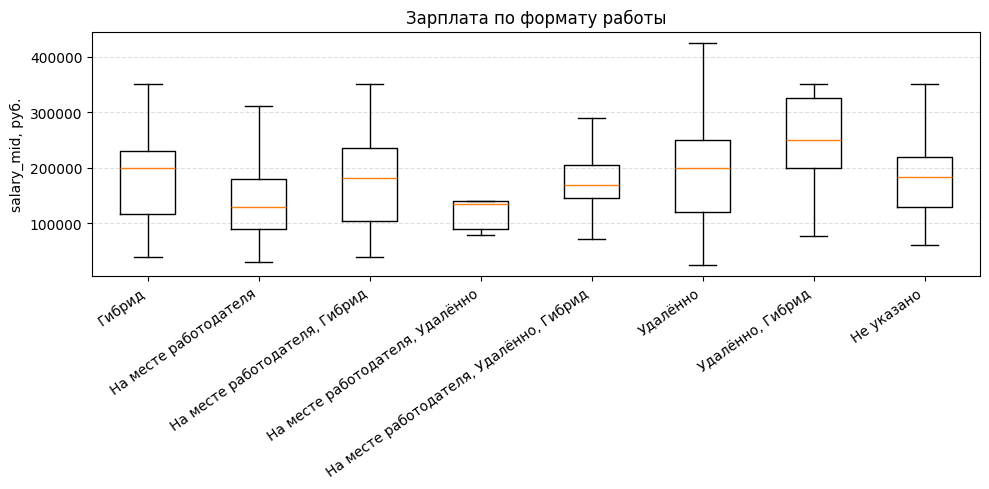

In [23]:
def boxplot_by_group(data, group_col, title, filename):
    groups = []
    labels = []
    for value, group in data.groupby(group_col, dropna=False):
        groups.append(group['salary_mid'].dropna())
        labels.append('Не указано' if pd.isna(value) else str(value))
    
    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, tick_labels=labels, showfliers=False)
    plt.title(title)
    plt.ylabel('salary_mid, руб.')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200)
    plt.show()

boxplot_by_group(df_clean, 'primary_role', 'Зарплата по направлениям аналитики', 'fig_3_8_salary_by_role.png')
boxplot_by_group(df_clean, 'city_group', 'Зарплата по городским группам', 'fig_3_9_salary_by_city.png')
boxplot_by_group(df_clean, 'experience_name', 'Зарплата по опыту работы', 'fig_3_10_salary_by_experience.png')
boxplot_by_group(df_clean, 'schedule_name', 'Зарплата по формату работы', 'fig_3_11_salary_by_schedule.png')

## 10. Частотность навыков

Считаем, как часто в вакансиях встречаются признаки навыков и требований. Это нужно для предварительного анализа данных; проверка связи навыков с зарплатой будет в параграфе 3.3.

In [24]:
skill_columns = [
    'has_sql', 'has_python', 'has_excel', 'has_power_bi', 'has_tableau', 'has_bi_tools',
    'has_dwh', 'has_etl', 'has_ml', 'has_statistics', 'has_ab_testing',
    'has_bpmn', 'has_uml', 'has_api', 'has_requirements', 'has_1c', 'has_jira'
]

skill_names = {
    'has_sql': 'SQL',
    'has_python': 'Python',
    'has_excel': 'Excel',
    'has_power_bi': 'Power BI',
    'has_tableau': 'Tableau',
    'has_bi_tools': 'BI-инструменты',
    'has_dwh': 'DWH',
    'has_etl': 'ETL',
    'has_ml': 'ML',
    'has_statistics': 'Статистика',
    'has_ab_testing': 'A/B-тестирование',
    'has_bpmn': 'BPMN',
    'has_uml': 'UML',
    'has_api': 'API',
    'has_requirements': 'Требования / ТЗ',
    'has_1c': '1C',
    'has_jira': 'Jira / Confluence',
}

skill_freq = []
for col in skill_columns:
    count = int(df_clean[col].fillna(0).sum())
    skill_freq.append([skill_names[col], count, round(count / len(df_clean) * 100, 2)])

skill_freq = pd.DataFrame(skill_freq, columns=['Навык / требование', 'Количество вакансий', 'Доля, %'])
skill_freq = skill_freq.sort_values('Количество вакансий', ascending=False).reset_index(drop=True)
skill_freq

,Навык / требование,Количество вакансий,"Доля, %"
0,Требования / ТЗ,572,83.38
1,BPMN,375,54.66
2,SQL,372,54.23
3,API,319,46.50
4,UML,209,30.47
5,Excel,199,29.01
6,Python,198,28.86
7,BI-инструменты,174,25.36
8,1C,153,22.30
9,Jira / Confluence,131,19.10


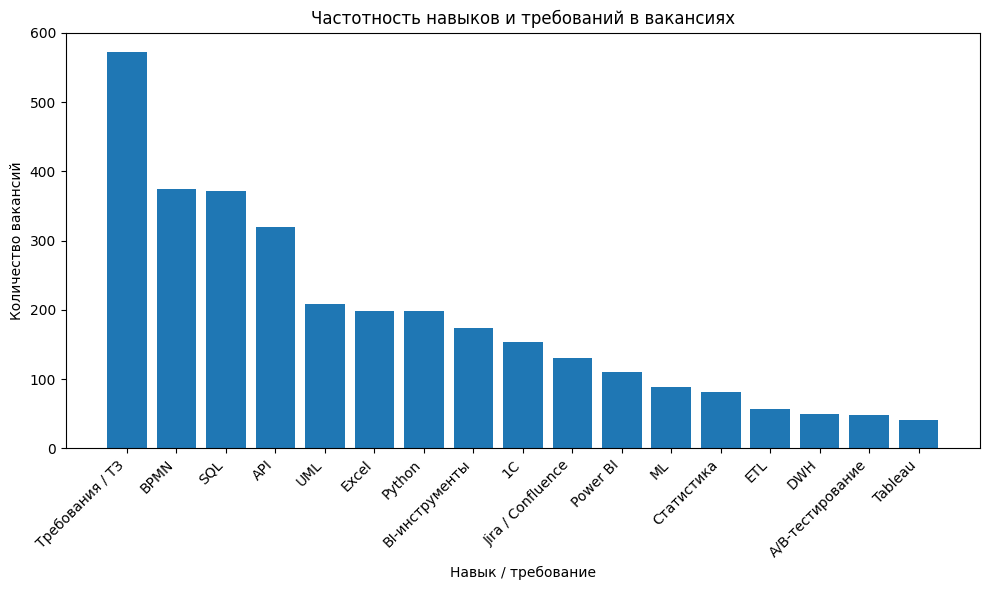

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(skill_freq['Навык / требование'], skill_freq['Количество вакансий'])
plt.title('Частотность навыков и требований в вакансиях')
plt.xlabel('Навык / требование')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_3_12_skill_frequency.png', dpi=200)
plt.show()

## 11. Краткие итоги для параграфа 3.1

Эта ячейка собирает основные числа, которые можно использовать при написании текста.

In [26]:
summary = {
    'Исходное количество вакансий': len(df),
    'Количество переменных': df.shape[1],
    'Рабочая выборка после проверки зарплат': len(df_clean),
    'Удалено некорректных зарплатных наблюдений': len(df) - len(df_clean),
    'Средняя salary_mid': round(df_clean['salary_mid'].mean(), 2),
    'Медианная salary_mid': round(df_clean['salary_mid'].median(), 2),
    'Минимальная salary_mid': round(df_clean['salary_mid'].min(), 2),
    'Максимальная salary_mid': round(df_clean['salary_mid'].max(), 2),
    'Самое частое направление': role_table.iloc[0]['Категория'],
    'Самая частая городская группа': city_table.iloc[0]['Категория'],
    'Самый частый опыт': experience_table.iloc[0]['Категория'],
}

summary_table = pd.DataFrame(summary.items(), columns=['Показатель', 'Значение'])
summary_table

,Показатель,Значение
0,Исходное количество вакансий,693
1,Количество переменных,41
2,Рабочая выборка после проверки зарплат,686
3,Удалено некорректных зарплатных наблюдений,7
4,Средняя salary_mid,171666.29
5,Медианная salary_mid,150000.0
6,Минимальная salary_mid,25000.0
7,Максимальная salary_mid,700000.0
8,Самое частое направление,System Analytics
9,Самая частая городская группа,Москва
